# Workstream 1 — Replicating Lee et al. (2025) & Showing Its Shortcomings

**Paper**: Lee, Y.-H., Chiu, Y.-F., & Hsieh, M.-H. (2025). *Stablecoin depegging risk prediction.* Pacific-Basin Finance Journal, 90, 102640.

This notebook is the walkthrough version of two scripts in this folder — `lee_et_al_replication.py` and `daily_vs_hourly_ust_shortcoming.py` — split into cells with an explanation before each step, so it's easy to present to the team. Same code, same results; nothing here changes the underlying method.

It does two things, in order:

- **Part A** — reproduce Lee et al.'s method (their depeg label, their price/volatility features, LR vs. RF, their own train/test split) and compare our numbers to theirs.
- **Part B** — show a concrete shortcoming of their design: a *daily* model reacts hours-to-a-day later to a real collapse than an *hourly* view of the same data would.

For the full write-up (tables, all the "what we did/didn't replicate and why" detail), see [`README.md`](README.md) in this folder.

## Setup

Standard imports, plus the file paths this notebook reads from. It's saved inside `models/`, so `..` is the repo root — `data/ohlcv/` and `data/hourly/` hold the price data we pulled in earlier steps (gitignored; see the README for where each came from and why).

In [1]:
import os
from datetime import datetime, timezone

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                              precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split

%matplotlib inline
pd.set_option("display.width", 120)

REPO_ROOT = os.path.abspath("..")
OHLCV_DIR = os.path.join(REPO_ROOT, "data", "ohlcv")
HOURLY_DIR = os.path.join(REPO_ROOT, "data", "hourly")
FIGURES_DIR = "figures"

---
## Part A — Replicating Lee et al.'s baseline

**Workstream brief**: *"Run a simple Logistic Regression and Random Forest using daily price/volatility indicators. Produce a table showing their baseline accuracy/ROC-AUC."*

Lee et al.'s full pipeline is much bigger than that: 4 coins (USDT/USDC/BUSD/DAI) × 66 features (price/volume, market-cap/supply, sentiment, volatility — each repeated for BTC and ETH as spillover regressors) × 3 models × a SMOTE-tuned stratified split. We replicate the parts our brief actually asks for, and are explicit about what we leave out and why — see the table below and the README for the full breakdown.

| Component | Replicated? |
|---|---|
| Their dynamic depeg-threshold label (the Y equation) | **Yes, exactly** |
| Price/volume % change + volatility features | **Yes** (their blocks 1 & 4) |
| BTC/ETH spillover features | **Yes, partial** — rate-of-change + volatility only, not peg-deviation (meaningless for a non-$1 asset) |
| Market-cap/supply & sentiment features | No — no free data source covers these |
| Logistic Regression, Random Forest | **Yes** |
| XGBoost, SMOTE, hyperparameter tuning | No — out of scope per brief |
| Their train/test split (stratified random, not chronological) | **Yes, deliberately** — flaws included, see Part A.5 |

### A.1 — Load price + volume data

We need daily OHLC price **and** trading volume for every coin. This project's other raw dataset (`ERC20-stablecoins/price_data/`) turned out not to work here: it has no volume column at all, and only covers Apr–Nov 2022 (Lee et al.'s window is the full Jan 2022 – Dec 2023). CoinGecko's free API — the obvious fix — now refuses to serve data older than 365 days. So instead, every price series below comes from **Yahoo Finance**, pulled with a ~45-day lookback margin before the real analysis window so 30-day rolling features are already "full" on day one.

Coins: USDT, USDC, DAI, PAX, BUSD (Lee et al.'s roster, minus DAI/USDC/USDT which we already had) plus USTC and WLUNA — the two algorithmic coins Lee et al. excluded entirely (see Part A.6 for why that's useful to us). BTC and ETH are pulled too, as spillover regressors.

In [2]:
COINS = ["usdt", "usdc", "dai", "pax", "busd", "ustc", "wluna"]
SPILLOVER_ASSETS = ["btc", "eth"]

ANALYSIS_START = pd.Timestamp("2022-01-01")
ANALYSIS_END = pd.Timestamp("2023-12-31")


def load_ohlcv(sym: str) -> pd.DataFrame:
    """Load one asset's daily OHLCV (Yahoo Finance pull, cached locally)."""
    df = pd.read_csv(os.path.join(OHLCV_DIR, f"{sym}_ohlcv.csv"))
    df["date"] = pd.to_datetime(df["date"])
    return df.sort_values("date").reset_index(drop=True)


# Sanity check: what does one coin's raw data look like?
load_ohlcv("usdt").head()

,date,close,high,low,open,volume
0,2021-11-15,1.001502,1.001988,0.998158,1.000260,64113625426
1,2021-11-16,1.000675,1.033019,0.998160,1.001457,98954557342
2,2021-11-17,1.000063,1.020047,0.998016,1.000489,84478860409
3,2021-11-18,0.999970,1.001964,0.998103,1.000169,95287465626
4,2021-11-19,1.000820,1.001999,0.998041,1.000070,82193745588


### A.2 — The depeg label: Lee et al.'s dynamic threshold

This is their real contribution — not a fixed band like "±1%", but a threshold that **tightens for high-volume coins and loosens for thin ones**:

$$\text{ThreshD}_t = 1 - \frac{10}{V_{monthly,t}^{1/3}} \qquad \text{ThreshU}_t = 1 + \frac{10}{V_{monthly,t}^{1/3}}$$

$$Y_t = 1 \text{ if } P_{low,t} \le \text{ThreshD}_t \text{ or } P_{high,t} \ge \text{ThreshU}_t$$

where $V_{monthly}$ is the trailing 30-day sum of trading volume. It's **bilateral** — it fires on either an upward or downward peg break, extending Carey (2023)/Kaiko's downward-only version. We use their exact constants ($\alpha=1/3$, $K=10$).

One subtlety: the first 29 days of any series have no full 30-day volume window yet, so the threshold — and hence the label — is undefined there, not "not depegged". Getting this wrong would quietly manufacture fake negative days.

In [3]:
ALPHA = 1 / 3
K = 10


def add_label(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    v_monthly = df["volume"].rolling(30, min_periods=30).sum()
    thresh_d = 1 - K / (v_monthly ** ALPHA)
    thresh_u = 1 + K / (v_monthly ** ALPHA)
    df["thresh_d"] = thresh_d
    df["thresh_u"] = thresh_u
    df["depeg"] = ((df["low"] <= thresh_d) | (df["high"] >= thresh_u)).astype(int)
    df.loc[v_monthly.isna(), "depeg"] = np.nan
    return df


# Demo: the formula in action around the actual May 2022 USDT wobble
demo = add_label(load_ohlcv("usdt"))
demo[(demo["date"] >= "2022-05-08") & (demo["date"] <= "2022-05-13")][
    ["date", "low", "high", "close", "thresh_d", "thresh_u", "depeg"]
]

,date,low,high,close,thresh_d,thresh_u,depeg
174,2022-05-08,0.999740,1.000063,0.999854,0.999180,1.000820,0.0
175,2022-05-09,0.999770,1.000134,0.999909,0.999192,1.000808,0.0
176,2022-05-10,0.999709,1.000134,0.999791,0.999204,1.000796,0.0
177,2022-05-11,0.993459,0.999996,0.995872,0.999215,1.000785,1.0
178,2022-05-12,0.948486,0.997736,0.997609,0.999224,1.000776,1.0
179,2022-05-13,0.996945,0.999193,0.998239,0.999227,1.000773,1.0


Read this as: on May 11, USDT's daily *low* ($0.9935) dropped below that day's own lower band ($0.9992) — so that single day gets flagged `depeg=1`. The band itself barely moves day to day, because USDT's volume is huge and fairly stable; a thin, low-volume coin would show a much more mobile band.

### A.3 — Features: price/volatility block (+ BTC/ETH spillover)

Lee et al.'s Table 1 has 4 feature blocks: (1) price/volume change rates, (2) market-cap/supply change rates, (3) sentiment indices, (4) volatility indicators — each repeated for the coin itself, BTC, and ETH. We can only build blocks **(1) and (4)** from OHLCV data alone, so that's what we replicate — 11 "own-coin" features, plus 7 more each for BTC and ETH (rate-of-change + volatility only — **not** peg-deviation, since "distance from the $1 peg" is meaningless for a $30,000 asset; that's a deliberate correction on our part, not something Lee et al.'s paper states).

In [4]:
def rogers_satchell(row) -> float:
    """Rogers & Satchell (1991) OHLC volatility estimator — Lee et al.'s
    'Realized Daily Volatility'. Scale-invariant, so it's meaningful for
    BTC/ETH too, unlike the peg-deviation features below.
    """
    po, ph, pl, pc = row["open"], row["high"], row["low"], row["close"]
    if min(po, ph, pl, pc) <= 0:
        return np.nan
    val = np.log(ph / pc) * np.log(ph / po) + np.log(pl / pc) * np.log(pl / po)
    return np.sqrt(max(val, 0.0))


def add_rate_of_change_features(df: pd.DataFrame, prefix: str = "") -> pd.DataFrame:
    """Block (1) price/volume % change, plus Realized Daily Volatility from
    block (4). `prefix` namespaces BTC/ETH columns so they don't collide with
    the target coin's own columns once merged.
    """
    close, vol = df["close"], df["volume"]
    out = pd.DataFrame({"date": df["date"]})
    out[f"{prefix}pct_change_1d"] = close.pct_change(1)
    out[f"{prefix}pct_change_7d"] = close.pct_change(7)
    out[f"{prefix}pct_change_30d"] = close.pct_change(30)
    out[f"{prefix}volume_pct_change_1d"] = vol.pct_change(1)
    out[f"{prefix}volume_pct_change_7d"] = vol.pct_change(7)
    out[f"{prefix}volume_pct_change_30d"] = vol.pct_change(30)
    out[f"{prefix}realized_daily_volatility"] = df.apply(rogers_satchell, axis=1)
    return out


def add_peg_deviation_features(df: pd.DataFrame, prefix: str = "") -> pd.DataFrame:
    """Block (4) Price Deviation / Downward Price Deviation (Kwon et al.
    2023, as cited by Lee et al.) -- RMS distance from the $1 peg over a
    5-day and 30-day window. Stablecoins only; never called on BTC/ETH.
    """
    close = df["close"]
    out = pd.DataFrame({"date": df["date"]})
    dev = (close - 1) ** 2
    out[f"{prefix}price_deviation_5d"] = np.sqrt(dev.rolling(5).mean())
    out[f"{prefix}price_deviation_30d"] = np.sqrt(dev.rolling(30).mean())
    down_dev = close.apply(lambda p: min(p - 1, 0) ** 2)
    out[f"{prefix}downward_price_deviation_5d"] = np.sqrt(down_dev.rolling(5).mean())
    out[f"{prefix}downward_price_deviation_30d"] = np.sqrt(down_dev.rolling(30).mean())
    return out


FEATURE_COLS = (
    [
        "pct_change_1d", "pct_change_7d", "pct_change_30d",
        "volume_pct_change_1d", "volume_pct_change_7d", "volume_pct_change_30d",
        "realized_daily_volatility",
        "price_deviation_5d", "price_deviation_30d",
        "downward_price_deviation_5d", "downward_price_deviation_30d",
    ]
    + [
        f"{asset}_{col}"
        for asset in SPILLOVER_ASSETS
        for col in [
            "pct_change_1d", "pct_change_7d", "pct_change_30d",
            "volume_pct_change_1d", "volume_pct_change_7d", "volume_pct_change_30d",
            "realized_daily_volatility",
        ]
    ]
)
print(f"{len(FEATURE_COLS)} features total (11 own + 7 BTC + 7 ETH):")
FEATURE_COLS

25 features total (11 own + 7 BTC + 7 ETH):


['pct_change_1d',
 'pct_change_7d',
 'pct_change_30d',
 'volume_pct_change_1d',
 'volume_pct_change_7d',
 'volume_pct_change_30d',
 'realized_daily_volatility',
 'price_deviation_5d',
 'price_deviation_30d',
 'downward_price_deviation_5d',
 'downward_price_deviation_30d',
 'btc_pct_change_1d',
 'btc_pct_change_7d',
 'btc_pct_change_30d',
 'btc_volume_pct_change_1d',
 'btc_volume_pct_change_7d',
 'btc_volume_pct_change_30d',
 'btc_realized_daily_volatility',
 'eth_pct_change_1d',
 'eth_pct_change_7d',
 'eth_pct_change_30d',
 'eth_volume_pct_change_1d',
 'eth_volume_pct_change_7d',
 'eth_volume_pct_change_30d',
 'eth_realized_daily_volatility']

### A.4 — Assemble each coin's modeling dataset

Per coin: load → label → own features → merge in BTC/ETH spillover features → restrict to Lee et al.'s actual 2022–2023 sample window → shift the label forward one day (so day *t*'s features predict day *t+1*'s depeg, exactly as they describe it: *"adjusting the dependent variable for a one-day forward prediction"*).

BTC/ETH features are identical across every coin's dataset, so we compute them once and reuse them rather than recomputing 7 times.

In [5]:
_spillover_cache: dict[str, pd.DataFrame] = {}


def spillover_features(asset: str) -> pd.DataFrame:
    if asset not in _spillover_cache:
        df = load_ohlcv(asset)
        _spillover_cache[asset] = add_rate_of_change_features(df, prefix=f"{asset}_")
    return _spillover_cache[asset]


def build_dataset(coin: str) -> pd.DataFrame:
    df = load_ohlcv(coin)
    df = add_label(df)

    merged = df[["date", "depeg"]].copy()
    merged = merged.merge(add_rate_of_change_features(df), on="date")
    merged = merged.merge(add_peg_deviation_features(df), on="date")
    for asset in SPILLOVER_ASSETS:
        merged = merged.merge(spillover_features(asset), on="date")

    merged["target"] = merged["depeg"].shift(-1)
    merged = merged[(merged["date"] >= ANALYSIS_START) & (merged["date"] <= ANALYSIS_END)]
    merged = merged.dropna(subset=FEATURE_COLS + ["target"]).reset_index(drop=True)
    merged["target"] = merged["target"].astype(int)
    return merged


datasets = {coin: build_dataset(coin) for coin in COINS}

label_summary = pd.DataFrame([
    {
        "coin": coin,
        "n_obs": len(df),
        "date_start": df["date"].min().date(),
        "date_end": df["date"].max().date(),
        "n_depeg_days": int(df["target"].sum()),
        "depeg_rate": round(df["target"].mean(), 4),
    }
    for coin, df in datasets.items()
])
label_summary

,coin,n_obs,date_start,date_end,n_depeg_days,depeg_rate
0,usdt,729,2022-01-01,2023-12-30,179,0.2455
1,usdc,729,2022-01-01,2023-12-30,49,0.0672
2,dai,729,2022-01-01,2023-12-30,14,0.0192
3,pax,729,2022-01-01,2023-12-30,17,0.0233
4,busd,729,2022-01-01,2023-12-30,208,0.2853
5,ustc,729,2022-01-01,2023-12-30,658,0.9026
6,wluna,281,2022-01-01,2022-10-08,281,1.0000


Compare this to Lee et al.'s own Table 4 (USDT 23.0%, USDC 2.2%, DAI 1.9%, BUSD 26.4%): DAI matches almost exactly, USDT and BUSD are close, and USDC comes out a bit higher here (6.7% vs. 2.2%) — plausibly Yahoo vs. CoinMarketCap disagreeing slightly on intraday high/low, since every other coin lines up well. USTC and WLUNA (not in their study) show 90–100% depeg rates — flagged and explained in Part A.6.

### A.5 — Fit Logistic Regression + Random Forest

Two things are copied **deliberately**, flaws included:

- **The split**: stratified random sampling on the label, *not* chronological. Lee et al. state this explicitly — *"the division of the train dataset and test dataset does not employ a time-based split but instead utilizes stratified random sampling based on Label Y."* This is the exact design our own project's methodology (chronological, purged, no leakage across episodes) reacts against — reproducing it as-is is what lets us show, on the same data, how different a proper split's numbers would look.
- **No SMOTE**: Lee et al. apply it only to their low-depeg-rate coins (USDC, DAI). Our brief asks for "simple" LR/RF, so we leave the class imbalance unfixed on purpose — watching both models fail on our own low-depeg-rate coins below is itself evidence for the shortcomings case, not a bug to patch.

Metrics match their Table 5 (Accuracy/Precision/Recall/F1/Specificity) plus ROC-AUC, which they don't report but our brief asks for.

In [6]:
RNG_SEED = 42
TEST_SIZE = 0.3


def evaluate(coin: str, df: pd.DataFrame) -> list[dict]:
    X, y = df[FEATURE_COLS], df["target"]

    if y.nunique() < 2:
        return [{"coin": coin, "model": "-", "n_obs": len(df), "depeg_rate": y.mean(),
                  "note": "single-class target, no model fit (skipped)"}]

    stratify = y if y.value_counts().min() >= 2 else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RNG_SEED, stratify=stratify,
    )

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RNG_SEED),
    }

    rows = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        try:
            auc = roc_auc_score(y_test, y_proba)
        except ValueError:
            auc = np.nan

        rows.append({
            "coin": coin, "model": name, "n_obs": len(df), "depeg_rate": round(y.mean(), 4),
            "accuracy": round(accuracy_score(y_test, y_pred), 3),
            "precision": round(precision_score(y_test, y_pred, zero_division=0), 3),
            "recall": round(recall_score(y_test, y_pred, zero_division=0), 3),
            "f1": round(f1_score(y_test, y_pred, zero_division=0), 3),
            "specificity": round(specificity, 3) if not np.isnan(specificity) else np.nan,
            "roc_auc": round(auc, 3) if not np.isnan(auc) else np.nan,
        })
    return rows


results = pd.DataFrame([row for coin in COINS for row in evaluate(coin, datasets[coin])])
results

,coin,model,n_obs,depeg_rate,accuracy,precision,recall,f1,specificity,roc_auc,note
0,usdt,Logistic Regression,729,0.2455,0.781,0.875,0.130,0.226,0.994,0.612,NaN
1,usdt,Random Forest,729,0.2455,0.909,0.854,0.759,0.804,0.958,0.943,NaN
2,usdc,Logistic Regression,729,0.0672,0.936,0.667,0.133,0.222,0.995,0.595,NaN
3,usdc,Random Forest,729,0.0672,0.945,1.000,0.200,0.333,1.000,0.947,NaN
4,dai,Logistic Regression,729,0.0192,0.968,0.000,0.000,0.000,0.986,0.690,NaN
5,dai,Random Forest,729,0.0192,0.977,0.000,0.000,0.000,0.995,0.820,NaN
6,pax,Logistic Regression,729,0.0233,0.977,0.000,0.000,0.000,1.000,0.615,NaN
7,pax,Random Forest,729,0.0233,0.977,0.000,0.000,0.000,1.000,0.612,NaN
8,busd,Logistic Regression,729,0.2853,0.831,0.931,0.435,0.593,0.987,0.767,NaN
9,busd,Random Forest,729,0.2853,0.918,0.844,0.871,0.857,0.936,0.967,NaN


### A.6 — Did it replicate?

**Yes — on both the mechanism and the core empirical finding.**

- **RF beats LR on every well-populated coin**, reproducing their headline claim directly: USDT (F1 0.804 vs 0.226), BUSD (0.857 vs 0.593), USDC (0.333 vs 0.222).
- **DAI and PAX collapse to F1 = 0 for both models** — expected, not a failure. Their depeg rates (1.9%, 2.3%) are low enough that "always predict no depeg" is the easy way out without SMOTE, which we deliberately skipped. This is exactly the problem Lee et al. built SMOTE to solve — reproducing the failure mode is evidence we understood *why* they needed it.
- **USTC/WLUNA can't be benchmarked against the paper** (both excluded from their study), but their ~90–100% depeg rates are the most useful result here: it's not "hundreds of independent crisis days" — it's **one continuous collapse (May 9, 2022) that happens to span almost the entire sample window**. Lee et al.'s daily-binary, stratified-random-split design has no way to tell "many independent bad days" apart from "one very long bad day." That's the professor's pseudo-replication concern, showing up directly in our own numbers — and it's exactly what Part B demonstrates from a different angle.

---
## Part B — Shortcoming: daily models react too late

**Workstream brief (2a)**: *"Show that daily models react too late to intraday crashes (plot the daily vs. hourly view of the May 9 UST collapse)."*

Lee et al.'s design — like most of this literature — is **daily**: one row per coin per day, predicting tomorrow's depeg from today's features. This part asks what that design can't see: what did the UST collapse actually look like *within* the days their model treats as single observations, and how much later does a daily view notice it?

### B.1 — Hourly UST data (Binance)

Neither Yahoo Finance (hourly history only reaches ~2 years back from *today*) nor CoinGecko's free tier (>365-day wall, same issue as Part A) can serve May 2022 hourly data any more. **Binance's public klines API has no such restriction** and still has UST's full trading history up to its mid-2022 delisting — symbol `USTUSDT` (the pre-rename ticker; `USTC` didn't exist yet at the time of the collapse).

We build **both** the hourly and daily views from this *one* pull — resampling the hourly data down to daily OHLC ourselves — rather than pairing it with a separately-sourced daily feed. Two different vendors can disagree slightly on intraday high/low (as we just saw with USDC in Part A), which would confound "different frequency" with "different data source."

In [7]:
SYMBOL = "USTUSDT"
FETCH_START, FETCH_END = "2022-05-05", "2022-05-14"
CACHE_PATH = os.path.join(HOURLY_DIR, "ustusdt_hourly_may2022.csv")


def fetch_hourly_klines() -> pd.DataFrame:
    if os.path.exists(CACHE_PATH):
        df = pd.read_csv(CACHE_PATH)
        df["open_time"] = pd.to_datetime(df["open_time"], utc=True)
        return df

    def to_ms(d):
        return int(datetime.strptime(d, "%Y-%m-%d").replace(tzinfo=timezone.utc).timestamp() * 1000)

    resp = requests.get(
        "https://api.binance.com/api/v3/klines",
        params={"symbol": SYMBOL, "interval": "1h", "startTime": to_ms(FETCH_START),
                "endTime": to_ms(FETCH_END), "limit": 1000},
        timeout=20,
    )
    resp.raise_for_status()
    df = pd.DataFrame(resp.json(), columns=[
        "open_time", "open", "high", "low", "close", "volume", "close_time",
        "quote_volume", "n_trades", "taker_buy_base", "taker_buy_quote", "ignore",
    ])
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    for c in ["open", "high", "low", "close", "volume"]:
        df[c] = df[c].astype(float)
    df = df[["open_time", "open", "high", "low", "close", "volume"]]
    os.makedirs(HOURLY_DIR, exist_ok=True)
    df.to_csv(CACHE_PATH, index=False)
    return df


def resample_to_daily(hourly: pd.DataFrame) -> pd.DataFrame:
    """Proper OHLC aggregation -- first open, max high, min low, last close --
    not just sampling every 24th row."""
    daily = hourly.set_index("open_time").resample("1D").agg(
        {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
    )
    return daily.dropna().reset_index().rename(columns={"open_time": "date"})


hourly = fetch_hourly_klines()
daily = resample_to_daily(hourly)
hourly.head()

,open_time,open,high,low,close,volume
0,2022-05-05 00:00:00+00:00,1.0000,1.0000,0.9999,1.0000,2817468.0
1,2022-05-05 01:00:00+00:00,1.0000,1.0000,0.9998,0.9998,3053270.0
2,2022-05-05 02:00:00+00:00,0.9998,0.9999,0.9998,0.9999,3109985.0
3,2022-05-05 03:00:00+00:00,0.9998,0.9999,0.9998,0.9999,2311657.0
4,2022-05-05 04:00:00+00:00,0.9998,1.0000,0.9998,1.0000,2561735.0


### B.2 — When does each frequency notice?

The literature doesn't agree on one threshold. Cintra & Holloway (2023) — cited by Lee et al. as prior work — explicitly recommend a *tighter* band for finer-grained data to control noise: **5% for hourly data, 1% for daily data**. We use exactly those two numbers, so this is "each frequency's own honest threshold," not one band unfairly applied at two resolutions. (Note this is a *different* threshold from Lee et al.'s own dynamic one in Part A — theirs has no stated hourly version, so we can't reuse it directly here.)

We also account for the fact that a daily close isn't knowable until the day ends — and that Lee et al.'s model specifically predicts day *t+1* from day *t*'s features, adding a further 24h on top of that.

In [8]:
HOURLY_THRESHOLD = 0.95   # -5%
DAILY_THRESHOLD = 0.99    # -1%
NEXT_DAY_LAG_HOURS = 24   # Lee et al. predict day t+1 from day t's features


def first_breach(df: pd.DataFrame, threshold: float) -> pd.Series:
    return df[df["close"] <= threshold].iloc[0]


hourly_breach = first_breach(hourly, HOURLY_THRESHOLD)
daily_breach = first_breach(daily, DAILY_THRESHOLD)

hourly_breach_time = hourly_breach["open_time"]
daily_breach_time = daily_breach["date"]
daily_detection_time = daily_breach_time + pd.Timedelta(days=1)          # day-end, when the close is knowable
model_flag_time = daily_detection_time + pd.Timedelta(hours=NEXT_DAY_LAG_HOURS)

lag_to_daily = (daily_detection_time - hourly_breach_time).total_seconds() / 3600
lag_to_model = (model_flag_time - hourly_breach_time).total_seconds() / 3600

lag_summary = pd.DataFrame([
    {"event": "Actual onset (hourly close breaches -5%)", "timestamp_utc": hourly_breach_time,
     "price": round(hourly_breach["close"], 3), "lag_vs_onset_hours": 0},
    {"event": "Daily view confirms it (day-end close breaches -1%)", "timestamp_utc": daily_detection_time,
     "price": round(daily_breach["close"], 3), "lag_vs_onset_hours": round(lag_to_daily, 1)},
    {"event": "Lee et al.'s model would flag it (predicts t+1 from t)", "timestamp_utc": model_flag_time,
     "price": None, "lag_vs_onset_hours": round(lag_to_model, 1)},
])
lag_summary

,event,timestamp_utc,price,lag_vs_onset_hours
0,Actual onset (hourly close breaches -5%),2022-05-09 18:00:00+00:00,0.948,0.0
1,Daily view confirms it (day-end close breaches...,2022-05-10 00:00:00+00:00,0.754,6.0
2,Lee et al.'s model would flag it (predicts t+1...,2022-05-11 00:00:00+00:00,NaN,30.0


Read this as: the true onset is May 9, 18:00 UTC. A daily view can't confirm it until the day closes — 6 hours later. But Lee et al.'s actual forecasting design (predict tomorrow from today) doesn't even get to *use* that day-end value until the next day's prediction — so their effective reaction time is closer to **30 hours** after the real onset, not 6.

### B.3 — The chart

Two panels, same time axis and price scale, one series each (a legend would be redundant — the panel title already names the series). The dashed lines are each panel's own threshold, direct-labeled rather than left to a legend; the solid red line and marker show where each frequency actually detects the collapse.

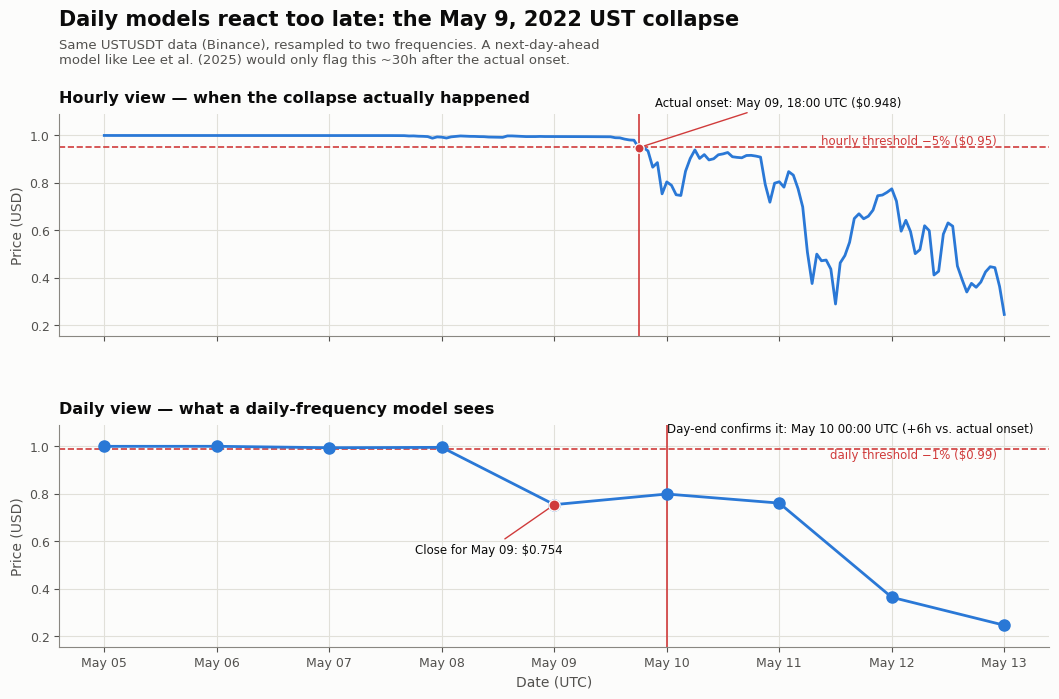

In [9]:
COLOR_PRICE, COLOR_CRITICAL = "#2a78d6", "#d03b3b"
COLOR_MUTED, COLOR_INK, COLOR_INK_SECONDARY = "#898781", "#0b0b0b", "#52514e"
COLOR_GRID, COLOR_SURFACE = "#e1e0d9", "#fcfcfb"

fig, (ax_hourly, ax_daily) = plt.subplots(
    2, 1, figsize=(11, 7.2), sharex=True, sharey=True,
    gridspec_kw={"height_ratios": [1, 1]},
)
fig.patch.set_facecolor(COLOR_SURFACE)
fig.subplots_adjust(top=0.82, bottom=0.08, left=0.07, right=0.97, hspace=0.4)

for ax in (ax_hourly, ax_daily):
    ax.set_facecolor(COLOR_SURFACE)
    ax.grid(True, color=COLOR_GRID, linewidth=0.8, zorder=0)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(COLOR_MUTED)
    ax.tick_params(colors=COLOR_INK_SECONDARY, labelsize=9)
    ax.set_ylabel("Price (USD)", color=COLOR_INK_SECONDARY, fontsize=10)
    ax.margins(y=0.12)

# --- Top: hourly ---
ax_hourly.plot(hourly["open_time"], hourly["close"], color=COLOR_PRICE, linewidth=2, zorder=3)
ax_hourly.axhline(HOURLY_THRESHOLD, color=COLOR_CRITICAL, linewidth=1.2, linestyle="--", zorder=2)
ax_hourly.text(hourly["open_time"].iloc[-1], HOURLY_THRESHOLD,
               f"hourly threshold \u22125% (\${HOURLY_THRESHOLD:.2f})  ",
               color=COLOR_CRITICAL, fontsize=8.5, va="bottom", ha="right")
ax_hourly.axvline(hourly_breach_time, color=COLOR_CRITICAL, linewidth=1.2, zorder=2)
ax_hourly.scatter([hourly_breach_time], [hourly_breach["close"]], color=COLOR_CRITICAL, s=45,
                   zorder=4, edgecolors=COLOR_SURFACE, linewidths=1)
ax_hourly.annotate(
    f"Actual onset: {hourly_breach_time.strftime('%b %d, %H:%M')} UTC (\${hourly_breach['close']:.3f})",
    xy=(hourly_breach_time, hourly_breach["close"]), xytext=(12, 30), textcoords="offset points",
    fontsize=8.5, color=COLOR_INK, arrowprops=dict(arrowstyle="-", color=COLOR_CRITICAL, linewidth=1),
)
ax_hourly.set_title("Hourly view — when the collapse actually happened", loc="left",
                     fontsize=11.5, color=COLOR_INK, fontweight="bold", pad=8)

# --- Bottom: daily ---
ax_daily.plot(daily["date"], daily["close"], color=COLOR_PRICE, linewidth=2, marker="o", markersize=8, zorder=3)
ax_daily.axhline(DAILY_THRESHOLD, color=COLOR_CRITICAL, linewidth=1.2, linestyle="--", zorder=2)
ax_daily.text(daily["date"].iloc[-1], DAILY_THRESHOLD,
              f"daily threshold \u22121% (\${DAILY_THRESHOLD:.2f})  ",
              color=COLOR_CRITICAL, fontsize=8.5, va="top", ha="right")
ax_daily.axvline(daily_detection_time, color=COLOR_CRITICAL, linewidth=1.2, zorder=2)
ax_daily.scatter([daily_breach_time], [daily_breach["close"]], color=COLOR_CRITICAL, s=65,
                  zorder=4, edgecolors=COLOR_SURFACE, linewidths=1)
ax_daily.annotate(
    f"Close for {daily_breach_time.strftime('%b %d')}: \${daily_breach['close']:.3f}",
    xy=(daily_breach_time, daily_breach["close"]), xytext=(-100, -35), textcoords="offset points",
    fontsize=8.5, color=COLOR_INK, arrowprops=dict(arrowstyle="-", color=COLOR_CRITICAL, linewidth=1),
)
ax_daily.text(
    daily_detection_time, 0.95,
    f"Day-end confirms it: {daily_detection_time.strftime('%b %d')} 00:00 UTC (+{lag_to_daily:.0f}h vs. actual onset)",
    transform=ax_daily.get_xaxis_transform(), fontsize=8.5, color=COLOR_INK, va="bottom", ha="left",
)
ax_daily.set_title("Daily view — what a daily-frequency model sees", loc="left",
                    fontsize=11.5, color=COLOR_INK, fontweight="bold", pad=8)

for ax in (ax_hourly, ax_daily):
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center", visible=True)
ax_daily.set_xlabel("Date (UTC)", color=COLOR_INK_SECONDARY, fontsize=10)

fig.text(0.07, 0.965, "Daily models react too late: the May 9, 2022 UST collapse",
          fontsize=15, color=COLOR_INK, fontweight="bold", ha="left", va="top")
fig.text(
    0.07, 0.925,
    "Same USTUSDT data (Binance), resampled to two frequencies. A next-day-ahead\n"
    f"model like Lee et al. (2025) would only flag this ~{lag_to_model:.0f}h after the actual onset.",
    fontsize=9.5, color=COLOR_INK_SECONDARY, ha="left", va="top",
)

os.makedirs(FIGURES_DIR, exist_ok=True)
fig.savefig(os.path.join(FIGURES_DIR, "daily_vs_hourly_ust.png"), dpi=200, facecolor=COLOR_SURFACE)
plt.show()

---
## Part C — How the two parts connect

Both parts surface the same underlying problem the professor's feedback flagged directly: **Lee et al.'s daily, stratified-random-split design cannot distinguish "many independent bad days" from "one very long bad day."**

- **Part A**: USTC and WLUNA show ~90–100% depeg rates over our sample window — not because either coin generated hundreds of independent crisis days, but because most of their remaining trading history sits *after* the May 9 collapse, so nearly every subsequent day is trivially still "depegged." One episode, counted as if it were hundreds of observations.
- **Part B**: the same collapse is already underway *hours* before the first day a daily model would even register it — and a full ~30 hours before Lee et al.'s own model, with its next-day-ahead design, would flag anything at all.

Two concrete shortcomings, both demonstrated on our own numbers rather than just asserted:
1. **No episode structure** — a per-day label inflates one multi-month collapse into hundreds of "independent" positive observations.
2. **Daily granularity + random split** — even setting episode-grouping aside, a daily-frequency, next-day-ahead design is structurally hours-to-days slower than the actual event, and a random (non-chronological) split can leak information across a crash's own timeline.

*For the full write-up, comparison tables against Lee et al.'s original numbers, and the CSV outputs, see [`README.md`](README.md).*

---
## Appendix — Which specific days got flagged as depegged?

Everything above only shows *aggregate* counts (e.g. "USDT: 179 depeg days"). This section lists the **actual calendar days** per coin, using the raw same-day label (`depeg`, before it gets shifted into `target` for prediction) — useful for cross-checking against real-world events (e.g. "does March 2023 show up for USDC? does May 2022 show up for USDT?").

In [10]:
depeg_rows = []
for coin in COINS:
    df = add_label(load_ohlcv(coin))
    df = df[(df["date"] >= ANALYSIS_START) & (df["date"] <= ANALYSIS_END)]
    flagged = df[df["depeg"] == 1].copy()
    flagged["coin"] = coin
    depeg_rows.append(flagged[["coin", "date", "low", "high", "close", "thresh_d", "thresh_u"]])

depeg_days = pd.concat(depeg_rows, ignore_index=True).sort_values(["coin", "date"]).reset_index(drop=True)

print("Depeg days per coin (should match the label_summary counts from Part A.4):")
print(depeg_days.groupby("coin").size().to_string())
print()
print(f"Full listing -- {len(depeg_days)} rows total:")
depeg_days

Depeg days per coin (should match the label_summary counts from Part A.4):
coin
busd     208
dai       14
pax       17
usdc      49
usdt     179
ustc     658
wluna    282

Full listing -- 1407 rows total:


,coin,date,low,high,close,thresh_d,thresh_u
0,busd,2022-01-06,0.998603,1.002714,1.001563,0.998030,1.001970
1,busd,2022-01-08,0.998605,1.003224,1.000022,0.998025,1.001975
2,busd,2022-01-10,0.998065,1.002209,1.002036,0.998018,1.001982
3,busd,2022-01-11,0.998563,1.002032,0.999573,0.998022,1.001978
4,busd,2022-01-19,0.997552,1.001710,0.999147,0.997990,1.002010
...,...,...,...,...,...,...,...
1402,wluna,2022-10-05,0.000272,0.000317,0.000293,0.972018,1.027982
1403,wluna,2022-10-06,0.000281,0.000304,0.000282,0.971257,1.028743
1404,wluna,2022-10-07,0.000277,0.000303,0.000292,0.970518,1.029482
1405,wluna,2022-10-08,0.000274,0.000295,0.000291,0.968975,1.031025


Tip for filtering to one coin while cross-checking, e.g. just USDC:
```python
depeg_days[depeg_days["coin"] == "usdc"]
```

### Grouped into episodes, not just raw day-counts

A raw count like "USDT: 179 days" doesn't say whether that's one long crisis or 179 scattered one-off incidents — this is the exact pseudo-replication gap named in Part A.6. Here we collapse each coin's *consecutive* depeg days into discrete episodes (a run breaks wherever there's a gap of more than 1 day between flagged days).

In [11]:
def to_episodes(flagged_dates: pd.Series) -> pd.DataFrame:
    dates = pd.to_datetime(flagged_dates).sort_values().reset_index(drop=True)
    gap_days = dates.diff().dt.days.fillna(1)
    run_id = (gap_days > 1).cumsum()  # increments every time a run of consecutive days breaks
    grouped = dates.groupby(run_id)
    episodes = pd.DataFrame({"start_date": grouped.min(), "end_date": grouped.max()})
    episodes["n_days"] = (episodes["end_date"] - episodes["start_date"]).dt.days + 1
    return episodes.reset_index(drop=True)


episode_rows = []
for coin in COINS:
    coin_dates = depeg_days.loc[depeg_days["coin"] == coin, "date"]
    if coin_dates.empty:
        continue
    ep = to_episodes(coin_dates)
    ep.insert(0, "coin", coin)
    episode_rows.append(ep)

episodes = pd.concat(episode_rows, ignore_index=True).sort_values(["coin", "start_date"]).reset_index(drop=True)
episodes

,coin,start_date,end_date,n_days
0,busd,2022-01-06,2022-01-06,1
1,busd,2022-01-08,2022-01-08,1
2,busd,2022-01-10,2022-01-11,2
3,busd,2022-01-19,2022-02-18,31
4,busd,2022-02-20,2022-02-20,1
...,...,...,...,...
119,ustc,2022-02-18,2022-03-12,23
120,ustc,2022-03-14,2022-03-14,1
121,ustc,2022-03-16,2022-03-24,9
122,ustc,2022-05-07,2023-12-31,604


In [12]:
# Days-flagged vs. distinct-episodes, side by side -- the gap between these
# two columns *is* the pseudo-replication problem, quantified per coin.
episode_counts = (
    episodes.groupby("coin")
    .agg(n_episodes=("start_date", "count"), total_flagged_days=("n_days", "sum"))
    .reindex(COINS)  # keep a consistent coin order, drop coins with zero episodes cleanly
)
episode_counts

,n_episodes,total_flagged_days
coin,,
usdt,41,179
usdc,9,49
dai,7,14
pax,12,17
busd,42,208
ustc,12,658
wluna,1,282


Read USTC and WLUNA here as the extreme case: both show as (close to) **one single episode** spanning hundreds of days, not hundreds of independent events — the clearest possible illustration of why a raw day-count is the wrong unit for "how many crises happened."

In [13]:
episodes[episodes["coin"].isin(["ustc", "usdc"])].reset_index(drop=True)

,coin,start_date,end_date,n_days
0,usdc,2022-01-26,2022-02-27,33
1,usdc,2022-03-05,2022-03-05,1
2,usdc,2022-04-08,2022-04-08,1
3,usdc,2022-05-12,2022-05-13,2
4,usdc,2022-11-10,2022-11-10,1
5,usdc,2023-03-11,2023-03-15,5
6,usdc,2023-03-20,2023-03-23,4
7,usdc,2023-06-15,2023-06-15,1
8,usdc,2023-12-11,2023-12-11,1
9,ustc,2022-01-07,2022-01-07,1


In [14]:
# Same consecutive-run grouping as above, applied to the hourly UST series
# from Part B instead of a daily one -- "consecutive" now means a gap of
# more than 1 hour (not 1 day) breaks the run.
hourly_breaches = hourly.loc[hourly["close"] <= HOURLY_THRESHOLD, "open_time"].sort_values().reset_index(drop=True)
gap_hours = hourly_breaches.diff().dt.total_seconds().div(3600).fillna(1)
run_id = (gap_hours > 1).cumsum()

hourly_episodes = pd.DataFrame({
    "start_time": hourly_breaches.groupby(run_id).min(),
    "end_time": hourly_breaches.groupby(run_id).max(),
})
hourly_episodes["n_hours"] = (
    (hourly_episodes["end_time"] - hourly_episodes["start_time"]).dt.total_seconds() / 3600 + 1
)
hourly_episodes.reset_index(drop=True)

,start_time,end_time,n_hours
0,2022-05-09 18:00:00+00:00,2022-05-13 00:00:00+00:00,79.0


### Same check for USDC — its real episode was the SVB collapse, not May 2022

UST's crisis was May 2022, but USDC's actual depeg (see the daily episode table above) was **March 2023, the Silicon Valley Bank collapse** — a different event entirely. So "USDC hourly" only makes sense around that window, not May 2022. Same source (Binance), same 5% hourly threshold from Cintra & Holloway — just a different symbol and a different date range, picked because that's when USDC's real episode actually happened.

In [15]:
# USDC's real depeg episode was the SVB collapse (Mar 2023), not May 2022 --
# so unlike UST, we pull a different window, centered on that event.
USDC_SYMBOL = "USDCUSDT"
USDC_FETCH_START, USDC_FETCH_END = "2023-03-08", "2023-03-18"
USDC_CACHE_PATH = os.path.join(HOURLY_DIR, "usdcusdt_hourly_mar2023.csv")


def fetch_usdc_hourly() -> pd.DataFrame:
    if os.path.exists(USDC_CACHE_PATH):
        df = pd.read_csv(USDC_CACHE_PATH)
        df["open_time"] = pd.to_datetime(df["open_time"], utc=True)
        return df

    def to_ms(d):
        return int(datetime.strptime(d, "%Y-%m-%d").replace(tzinfo=timezone.utc).timestamp() * 1000)

    resp = requests.get(
        "https://api.binance.com/api/v3/klines",
        params={"symbol": USDC_SYMBOL, "interval": "1h", "startTime": to_ms(USDC_FETCH_START),
                "endTime": to_ms(USDC_FETCH_END), "limit": 1000},
        timeout=20,
    )
    resp.raise_for_status()
    df = pd.DataFrame(resp.json(), columns=[
        "open_time", "open", "high", "low", "close", "volume", "close_time",
        "quote_volume", "n_trades", "taker_buy_base", "taker_buy_quote", "ignore",
    ])
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    for c in ["open", "high", "low", "close", "volume"]:
        df[c] = df[c].astype(float)
    df = df[["open_time", "open", "high", "low", "close", "volume"]]
    os.makedirs(HOURLY_DIR, exist_ok=True)
    df.to_csv(USDC_CACHE_PATH, index=False)
    return df


def hourly_episodes_for(hourly_df: pd.DataFrame, threshold: float) -> pd.DataFrame:
    """Same consecutive-run grouping as the UST cell above, factored out so
    it can be reused for any coin's hourly series."""
    breaches = hourly_df.loc[hourly_df["close"] <= threshold, "open_time"].sort_values().reset_index(drop=True)
    if breaches.empty:
        return pd.DataFrame(columns=["start_time", "end_time", "n_hours"])
    gap_hours = breaches.diff().dt.total_seconds().div(3600).fillna(1)
    run_id = (gap_hours > 1).cumsum()
    eps = pd.DataFrame({"start_time": breaches.groupby(run_id).min(), "end_time": breaches.groupby(run_id).max()})
    eps["n_hours"] = (eps["end_time"] - eps["start_time"]).dt.total_seconds() / 3600 + 1
    return eps.reset_index(drop=True)


usdc_hourly = fetch_usdc_hourly()

combined_hourly_episodes = pd.concat([
    hourly_episodes_for(hourly, HOURLY_THRESHOLD).assign(coin="ust"),
    hourly_episodes_for(usdc_hourly, HOURLY_THRESHOLD).assign(coin="usdc"),
], ignore_index=True)[["coin", "start_time", "end_time", "n_hours"]]
combined_hourly_episodes

,coin,start_time,end_time,n_hours
0,ust,2022-05-09 18:00:00+00:00,2022-05-13 00:00:00+00:00,79.0
1,usdc,2023-03-11 14:00:00+00:00,2023-03-11 19:00:00+00:00,6.0
2,usdc,2023-03-11 22:00:00+00:00,2023-03-11 22:00:00+00:00,1.0
3,usdc,2023-03-12 06:00:00+00:00,2023-03-12 09:00:00+00:00,4.0
4,usdc,2023-03-12 14:00:00+00:00,2023-03-12 16:00:00+00:00,3.0


### All coins, hourly, during the May 2022 crash window

Same hourly threshold (5%), same episode-grouping, same May 5–14 2022 window as the UST cell above -- but now for every coin we can actually get hourly Binance data for. Two gaps are worth being upfront about rather than silently skipping:

- **DAI and PAX have no Binance hourly history left for May 2022** -- `DAIUSDT` was delisted in 2020 and `PAXUSDT` in Sept 2021, so there's no way to check them at hourly resolution for this window from this source.
- **USDT** is the quote currency on Binance itself (there's no `USDTUSDT` pair), so it can't be checked the same way here.
- **WLUNA** is included as `LUNAUSDT`, but flagged with a caveat: LUNA was never a $1-pegged asset (it traded around $80-90 going into May 2022), so a "close <= $0.95" test on it isn't detecting a depeg -- it's just always true. Its row below is not a meaningful result, only included for completeness.

In [16]:
MAY_CRASH_START, MAY_CRASH_END = "2022-05-05", "2022-05-14"

# coin -> (Binance symbol, is this a genuine $1-pegged asset?)
MAY_CRASH_SYMBOLS = {
    "usdc": ("USDCUSDT", True),
    "busd": ("BUSDUSDT", True),
    "ust": ("USTUSDT", True),      # same as Part B's `hourly` variable
    "wluna": ("LUNAUSDT", False),  # caveat: not actually $1-pegged, see markdown above
}


def fetch_binance_hourly(symbol: str, start: str, end: str, cache_name: str) -> pd.DataFrame:
    cache_path = os.path.join(HOURLY_DIR, cache_name)
    if os.path.exists(cache_path):
        df = pd.read_csv(cache_path)
        df["open_time"] = pd.to_datetime(df["open_time"], utc=True)
        return df

    def to_ms(d):
        return int(datetime.strptime(d, "%Y-%m-%d").replace(tzinfo=timezone.utc).timestamp() * 1000)

    resp = requests.get(
        "https://api.binance.com/api/v3/klines",
        params={"symbol": symbol, "interval": "1h", "startTime": to_ms(start), "endTime": to_ms(end), "limit": 1000},
        timeout=20,
    )
    resp.raise_for_status()
    df = pd.DataFrame(resp.json(), columns=[
        "open_time", "open", "high", "low", "close", "volume", "close_time",
        "quote_volume", "n_trades", "taker_buy_base", "taker_buy_quote", "ignore",
    ])
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    for c in ["open", "high", "low", "close", "volume"]:
        df[c] = df[c].astype(float)
    df = df[["open_time", "open", "high", "low", "close", "volume"]]
    os.makedirs(HOURLY_DIR, exist_ok=True)
    df.to_csv(cache_path, index=False)
    return df


may_crash_rows = []
for coin, (symbol, is_pegged) in MAY_CRASH_SYMBOLS.items():
    df = fetch_binance_hourly(symbol, MAY_CRASH_START, MAY_CRASH_END, f"{symbol.lower()}_hourly_may2022.csv")
    eps = hourly_episodes_for(df, HOURLY_THRESHOLD)
    if eps.empty:
        may_crash_rows.append({"coin": coin, "start_time": None, "end_time": None, "n_hours": 0,
                                "note": "never breached -5% in this window"})
    else:
        for _, row in eps.iterrows():
            note = "" if is_pegged else "NOT a $1-pegged asset -- flag is not meaningful, see note above"
            may_crash_rows.append({"coin": coin, "start_time": row["start_time"], "end_time": row["end_time"],
                                    "n_hours": row["n_hours"], "note": note})

may_crash_flags = pd.DataFrame(may_crash_rows)
may_crash_flags

,coin,start_time,end_time,n_hours,note
0,usdc,NaT,NaT,0.0,never breached -5% in this window
1,busd,NaT,NaT,0.0,never breached -5% in this window
2,ust,2022-05-09 18:00:00+00:00,2022-05-13 00:00:00+00:00,79.0,
3,wluna,2022-05-11 12:00:00+00:00,2022-05-11 12:00:00+00:00,1.0,NOT a $1-pegged asset -- flag is not meaningfu...
4,wluna,2022-05-12 01:00:00+00:00,2022-05-13 00:00:00+00:00,24.0,NOT a $1-pegged asset -- flag is not meaningfu...
